In [25]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [ ]:
"""
This module takes care of loading data and preparing it for model training.

"""

import os
import json

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


_NLCD_CLASSES = [
    11,
    12,
    21,
    22,
    23,
    24,
    31,
    41,
    42,
    43,
    51,
    52,
    71,
    72,
    73,
    74,
    81,
    82,
    90,
    95,
]
_GREEN_CLASSES = [0, 2, 4, 6, 8, 10, 12, 13, 14]


class GreenspaceDataset(Dataset):
    """
    The data is assumed to be in the directory as a set of files.

    Each file is a JSON containing the following keys:
        - temp: the temperature
        - coords: the coordinates of the center of the window (in EPSG:5070).
        - nlcd_window: an array of shape (window_size, window_size) containing the NLCD class values as a one-hot encoding.
        - greenspace_window: an array of shape (window_size, window_size) containing the greenspace class values as a one-hot encoding.
        - ndvi_albedo_window: an array of shape (window_size, window_size) containing the NDVI and albedo values as a two-channel image.

    """

    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.file_list = [f for f in os.listdir(data_dir) if f.endswith(".json")]

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_dir, self.file_list[idx])
        with open(file_path) as f:
            data = json.load(f)

        coords = torch.tensor(data["coords"], dtype=torch.float32)
        elev = torch.tensor(data["elev"], dtype=torch.float32)
        nlcd_window = torch.tensor(data["nlcd_window"])
        greenspace_window = torch.tensor(data["greenspace_window"])
        ndvi_albedo_window = torch.tensor(data["ndvi_albedo_window"])
        temp = torch.tensor(data["temp"], dtype=torch.float32)

        nlcd_oh = self._create_one_hot(nlcd_window, _NLCD_CLASSES).permute(2, 0, 1)  # (C, H, W)
        gs_oh = self._create_one_hot(greenspace_window, _GREEN_CLASSES).permute(2, 0, 1)  # (C, H, W)

        # Add the NDVI and albedo channels to the stacked window
        stacked_window = torch.cat([nlcd_oh, gs_oh, ndvi_albedo_window], dim=0)

        return coords, elev, stacked_window, temp

    def _create_one_hot(self, window, class_values):
        indices = torch.zeros_like(window)
        for idx, val in enumerate(class_values):
            indices[window == val] = idx
        return F.one_hot(indices, num_classes=len(class_values)).float()

In [101]:
gs = GreenspaceDataset("../asheville")


In [95]:
c, e, n, g, na, t = gs[1]

In [99]:
na.shape

torch.Size([2, 51, 51])

In [103]:
es = []

for c, e, s, t in gs:
    es.append(e.item())

In [109]:
import numpy as np
sum(np.array(es) > 1000)

np.int64(271)

(array([5743., 7892.,  870.,  201.,    0.,    0.,    0.,    0.,    0.,
         271.]),
 array([ 587. ,  653.9,  720.8,  787.7,  854.6,  921.5,  988.4, 1055.3,
        1122.2, 1189.1, 1256. ]),
 <BarContainer object of 10 artists>)

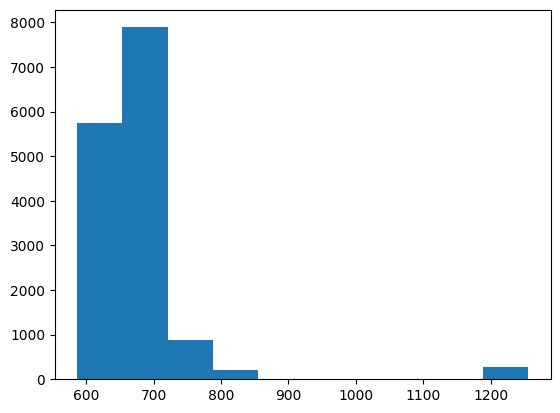

In [110]:
plt.hist(es)

In [ ]:
import os

class CustomDataset(Dataset):
    def __init__(self, base_path):
        self.base_path = base_path
        self.files = os.listdir(base_path)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        return self.data[idx]


In [4]:
import json


with open('../asheville/0.json') as f:
    data = json.load(f)

In [ ]:
ex = torch.tensor(data['nlcd_window'])
nlcd_indices = torch.zeros_like(ex)
for idx, nlcd_val in enumerate(_NLCD_CLASSES):
    nlcd_indices[ex == nlcd_val] = idx

nlcd_oh = F.one_hot(nlcd_indices, num_classes=len(_NLCD_CLASSES))

In [35]:
ex = torch.tensor(data['greenspace_window'])
gs_indices = torch.zeros_like(ex)
for idx, gs_val in enumerate(_GREEN_CLASSES):
    gs_indices[ex == gs_val] = idx

gs_oh = F.one_hot(gs_indices, num_classes=len(_GREEN_CLASSES))